Week 3: Data Preparation, Visualization and Feature Extraction

1. Follow along with these steps: 
a) Create a figure object called fig using plt.figure() 
b) Use add_axes to add an axis to the figure canvas at [0,0,1,1]. Call this new axis ax. 
c) Plot (x,y) on that axes and set the labels and titles to match the plot below:

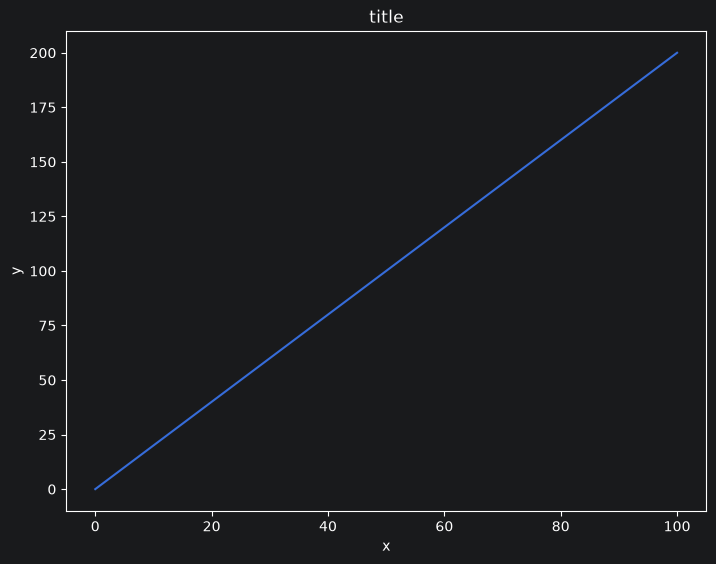

In [1]:
import matplotlib.pyplot as plt
import numpy as np
x = np.linspace(0, 100, 11)
y = x * 2

fig = plt.figure()

ax = fig.add_axes([0, 0, 1, 1])

ax.plot(x,y)
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("title")

# Display the plot
plt.show()


2. Create a figure object and put two axes on it, ax1 and ax2. Located at [0,0,1,1] and 
[0.2,0.5,.2,.2] respectively. Now plot (x,y) on both axes. And call your figure object to show 
it. 

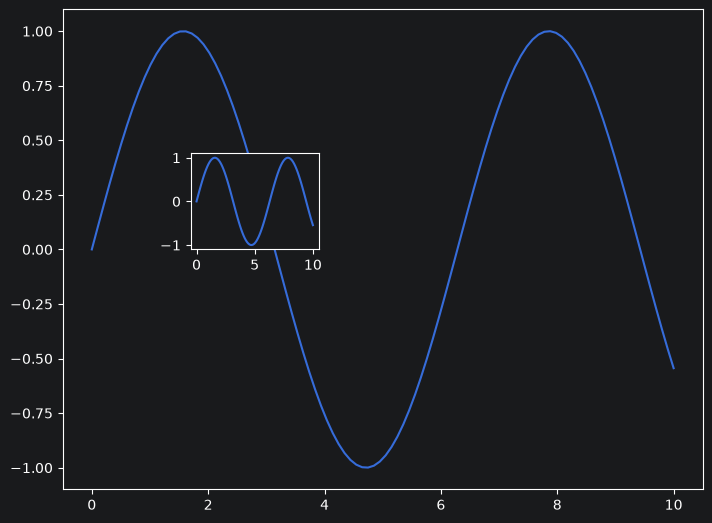

In [2]:
import numpy as np
x = np.linspace(0, 10, 100)
y = np.sin(x)

# 1
fig = plt.figure()

# 2. two axes [left, bottom, width, height]
ax1 = fig.add_axes([0, 0, 1, 1])
ax2 = fig.add_axes([0.2, 0.5, 0.2, 0.2])

# 3. 
ax1.plot(x, y)
ax2.plot(x, y)

# 4.
plt.show()


3. Use the company sales dataset csv file, read Total profit of all months and show it using a 
line plot.

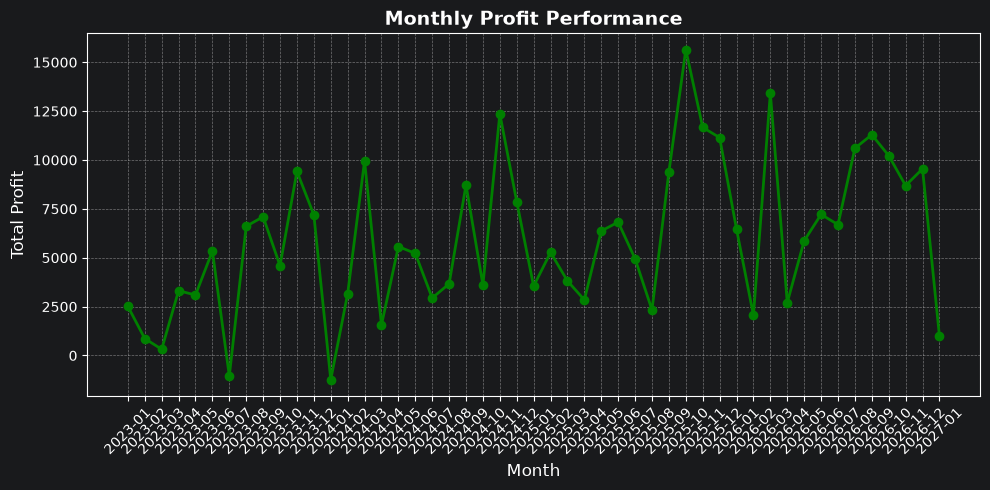

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('salesData.csv', encoding='latin1')
# print(df.describe())

df['Date'] = pd.to_datetime(df['Ship Date'])
df['Month'] = df['Date'].dt.strftime('%Y-%m') 
monthly_profit = df.groupby('Month')['Profit'].sum().reset_index()
# print(monthly_profit)

# 4. Plot the graph
plt.figure(figsize=(10, 5))
plt.plot(monthly_profit['Month'], monthly_profit['Profit'], marker='o', color='green', linewidth=2)

# 5. Graph styling
plt.title('Monthly Profit Performance', fontsize=14, fontweight='bold')
plt.xlabel('Month', fontsize=12)
plt.ylabel('Total Profit', fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

4. A retail company recorded advertising_spend and monthly_sales for 50 stores. Plot a scatter plot to
visualize the relationship. Based on the pattern, would you recommend increasing the ad budget?
Support your answer with the correlation coefficient.

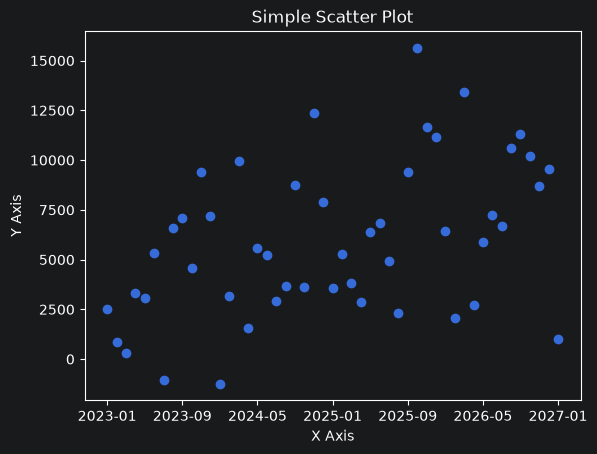

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

df = pd.read_csv('salesData.csv', encoding='latin1')
# print(df.describe())

df['Date'] = pd.to_datetime(df['Ship Date'])
df['Month'] = df['Date'].dt.strftime('%Y-%m')
monthly_profit = df.groupby('Month')['Profit'].sum().reset_index()
# print(monthly_profit)

plt.scatter(monthly_profit['Month'],monthly_profit['Profit'])
plt.title("Simple Scatter Plot")
plt.xlabel("X Axis")
plt.ylabel("Y Axis")

# Limit the X-axis to a maximum of 5 ticks
plt.gca().xaxis.set_major_locator(MaxNLocator(nbins=7))

plt.show()

5. A school wants to know if hours_studied predicts exam_score for 200 students, but also wants to see
if this relationship differs between students who attended extra tutoring vs. those who didn't. Create a
scatter plot color-coded by tutoring status and interpret the result

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# 1. Generate synthetic dataset for 200 students
np.random.seed(42)
n_students = 200

hours_studied = np.random.uniform(1, 10, n_students)
tutoring = np.random.choice(["Attended", "Did Not Attend"], size=n_students, p=[0.5, 0.5])

# Exam scores: base score + effect of hours + bonus for tutoring + random noise
noise = np.random.normal(0, 5, n_students)
exam_score = (
    40
    + 4.5 * hours_studied
    + np.where(tutoring == "Attended", 15, 0)
    + noise
)
exam_score = np.clip(exam_score, 0, 100)

df = pd.DataFrame({
    "hours_studied": hours_studied,
    "exam_score": exam_score,
    "tutoring": tutoring
})

# 2. Create the color-coded scatter plot with trend lines
plt.figure(figsize=(9, 6))
sns.scatterplot(
    data=df,
    x="hours_studied",
    y="exam_score",
    hue="tutoring",
    style="tutoring",
    palette={"Attended": "#2b5c8f", "Did Not Attend": "#d95f02"},
    s=65,
    alpha=0.85
)

# Optional: Add regression trendlines for visual comparison
sns.regplot(
    data=df[df["tutoring"] == "Attended"],
    x="hours_studied", y="exam_score",
    scatter=False, color="#2b5c8f", line_kws={"linewidth": 2, "label": "Trend: Attended"}
)
sns.regplot(
    data=df[df["tutoring"] == "Did Not Attend"],
    x="hours_studied", y="exam_score",
    scatter=False, color="#d95f02", line_kws={"linewidth": 2, "linestyle": "--", "label": "Trend: No Tutoring"}
)

plt.title("Exam Score vs. Hours Studied by Tutoring Status (N=200)", fontsize=13, weight="bold")
plt.xlabel("Hours Studied", fontsize=11)
plt.ylabel("Exam Score", fontsize=11)
plt.ylim(30, 105)
plt.legend(title="Tutoring Status", frameon=True)
plt.grid(True, linestyle=":", alpha=0.6)
plt.tight_layout()
plt.show()